# P4 - Projecttile Motion

**Objective:** Build a projectile motion simulation with and without air resistance in Python, producing two publication-quality plots that could be projected in a physics lecture or lab.

**Tools:** Python 3, numpy, matplotlib, scipy (for scipy.integrate.solve_ivp).

**Resources:** Newman *Computational Physics* (available online) — Chapter 8 covers ordinary differential equations and is directly relevant. scipy.integrate documentation for solve_ivp (use method='RK45'). Standard fluid dynamics: drag force F_drag = ½ρC_dAv².

**Instructions:**

1. Define your inputs as variables at the top of the script (easy to change for classroom demo): initial speed v₀ (m/s), launch angle θ (degrees), mass m (kg), drag coefficient C_d (dimensionless — use 0.47 for a sphere), cross-sectional area A (m²), air density ρ (1.225 kg/m³ at sea level).
2. Implement the equations of motion with drag as a system of ODEs:
    - dx/dt = v_x
    - dy/dt = v_y
    - dv_x/dt = -(ρ C_d A / 2m) · v_x · |v|
    - dv_y/dt = -g - (ρ C_d A / 2m) · v_y · |v|
    
    where |v| = √(v_x² + v_y²).
    
3. Solve using scipy.integrate.solve_ivp with method='RK45'. Also solve the ideal case (no drag) analytically: x(t) = v₀cos(θ)t, y(t) = v₀sin(θ)t - ½gt².
4. **Plot 1 — Trajectory:** Plot x vs. y for both cases (ideal and with drag) on the same axes. Label curves, add axis labels and a title. Mark the landing point for each case. Add a text annotation showing range difference.
5. **Plot 2 — Range vs. Launch Angle:** Sweep launch angle from 1° to 89° in 1° increments. For each angle, compute range for both ideal and drag cases. Plot range vs. angle for both on the same axes. With no drag, max range is at 45° — show this. With drag, the optimal angle shifts below 45° — show this too and label the actual optimal angle.
6. Comment every block of code. A student reading this without you present should understand what each section is doing and why.

**Deliverable:** Python script (or Jupyter notebook) with simulation, two plots, thorough comments. Push to GitHub.

In [195]:
import math as m
import numpy as np
import matplotlib.pyplot as plt

## Variable Definition

In [196]:
## Initial Conditions
v_0 = 25 # m/s
theta_launch = 30 # degrees
mass = 10 # kg
C_d = 0.47 # drag coefficient for a sphere
R_sphere = 0.1 # m
rho_air = 1.225 # kg / m^3

x_0 = 0 # m
y_0 = 0 # m
start_time = 0 # s

## Derived Quantities
CS_Area = m.pi*R_sphere**2 # m^2

## Derivations and Equations

$range_x = v_{0,x} t + \frac{1}{2}a_xt^2$

$range_y = v_{0,y} t + \frac{1}{2}a_yt^2$

$v_{0,x} = v_0 cos(\theta)$

$v_{0,y} = v_0 sin(\theta)$

---

$\frac{dv_x}{dt} = -\frac{\rho C_d A}{2m} \dot v_x \dot |v|$

$\frac{dv_y}{dt} = -g-\frac{\rho C_d A}{2m} \dot v_x \dot |v|$

where $|v| = \sqrt{v_x^2 + v_y^2}$

In [197]:
v_0x = v_0 * m.cos(m.radians(theta_launch)) # m/s
v_0y = v_0 * m.sin(m.radians(theta_launch)) # m/s

a_x = 0 # m/s^2
a_y = -9.81 # m/s^2

print(f"Initial x velocity: {v_0x:.2f} m/s")
print(f"Initial y velocity: {v_0y:.2f} m/s")
print(f"Acceleration in the x direction: {a_x:.2f} m/s^2")
print(f"Acceleration in the y direction: {a_y:.2f} m/s^2")

Initial x velocity: 21.65 m/s
Initial y velocity: 12.50 m/s
Acceleration in the x direction: 0.00 m/s^2
Acceleration in the y direction: -9.81 m/s^2


### Creating a function to calculate the range in the x and y directions

In [198]:
def x_range_func (v_init_x, acc_x, time_x):
    x_range_calc = v_init_x*time_x + 0.5*acc_x*time_x**2
    return x_range_calc

def y_range_func (v_init_y, acc_y, time_y):
    y_range_calc = v_init_y*time_y + 0.5*acc_y*time_y**2
    return y_range_calc

def dv_x_func (v_x_prev, acc_x, time_x):
    dv_x_step = m.sqrt(v_x_prev**2 + acc_x*time_x)
    return dv_x_step

def dv_y_func (v_y_prev, acc_y, time_y):
    dv_y_step = m.sqrt(v_y_prev**2 + acc_y*time_y)
    return dv_y_step

## Code Structure and Calculations

### Creating matrix structure to store iterative valves

In [199]:
MASTER_MATRIX = np.zeros((100, 5)) # Initialize a 2x2 matrix with zeros
MASTER_MATRIX[0, 0] = start_time # time
MASTER_MATRIX[0, 1] = x_0 # x position
MASTER_MATRIX[0, 2] = y_0 # y position

#print("time (s) | x position (m) | y position (m)")
#print(MASTER_MATRIX)


### Calculation and Loops

In [200]:
y_pos = y_0
time = start_time
time_step= 0.1 # seconds

while y_pos >= 0:
    time += time_step # Increment time by 0.1 seconds
    
    curr_v_x = dv_x_func(v_0x, a_x, time)
    curr_v_y = dv_y_func(v_0y, a_y, time)

    x_pos = x_range_func(curr_v_x, a_x, time)
    y_pos = y_range_func(curr_v_y, a_y, time)

    MASTER_MATRIX[int(time*10), 0] = time
    MASTER_MATRIX[int(time*10), 1] = x_pos
    MASTER_MATRIX[int(time*10), 2] = y_pos
    MASTER_MATRIX[int(time*10), 3] = curr_v_x
    MASTER_MATRIX[int(time*10), 4] = curr_v_y

In [201]:
#print("time (s) | x position (m) | y position (m)")
#print(MASTER_MATRIX)

## Plots and Data Viz

In [202]:
y_data = MASTER_MATRIX[:,2]
time_data = MASTER_MATRIX[:,0]

Text(0, 0.5, 'Y Position (m)')

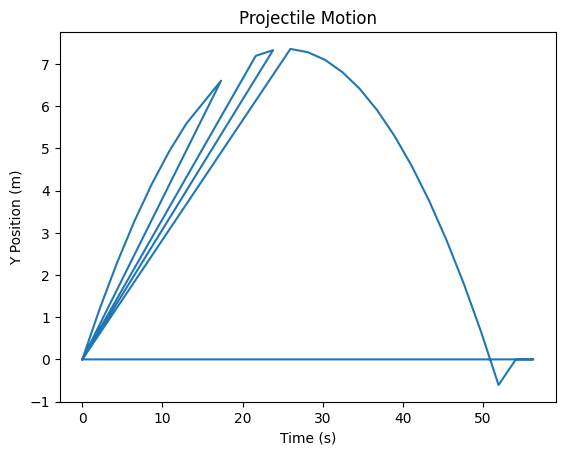

In [203]:
plt.plot(x_data, y_data)
plt.title("Projectile Motion")
plt.xlabel("Time (s)")
plt.ylabel("Y Position (m)")